In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys

import numpy as np
import nibabel as nb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from tqdm.auto import tqdm
    
sys.path.insert(1, "../../")
import precision_mapping as pm
import xmath_tools as xmt
import CAP_tools

sys.path.insert(1, "../../network_control")
import surface_mapping as sfm

# Create Cifti List 

In [2]:
cifti_dir = "/home/cole/_research/data/HCP_7T_ciftis"

cifti_paths = sorted(glob.glob(f"{cifti_dir}/*.dtseries.nii"))
subjects = [path.split("--", maxsplit=3)[1] for path in cifti_paths]

In [3]:
for path in tqdm(cifti_paths):
    path
    # cifti = nb.load(path)
    # data = cifti.get_fdata(caching="unchanged")

  0%|          | 0/177 [00:00<?, ?it/s]

# Compare 2 ciftis vFC

In [4]:
cifti = nb.load(cifti_paths[0])
cifti2 = nb.load(cifti_paths[1])

data1 = cifti.get_fdata(caching="unchanged").astype("float16")
data2 = cifti2.get_fdata(caching="unchanged").astype("float16")

In [14]:
pair_data = np.stack((data1[:1800], data1[-1800:]), axis=2).astype("float16")

In [25]:
r = xmt.PairCorrelator.run(pair_data, axis=None, threshold=None, backend="torch", device="cuda")

# r_axis = xmt.pair_correlation(pair_data, axis=1, leave=True, block_size=2000, backend="torch", device="cuda")

PairCorrelator Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

In [26]:
r

np.float64(0.36139999999999994)

# Example of Paired vFC correlation

In [7]:
def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

In [12]:
r_axis_cortex = pm.na.get_cortex_data(r_axis.reshape(1, -1), cifti)

In [ ]:
ax, _ = vertex_plot(r_axis_cortex[0], cifti, cmap=plt.cm.Spectral)

In [14]:
r_axis_cortex

array([[0.5749427 , 0.44233912, 0.24610576, ..., 0.4313175 , 0.47654042,
        0.39208448]], dtype=float32)

In [7]:
values = {"left": r_axis[:32_192], "right": r_axis[32_192:32_192 * 2]}

In [15]:
32_192 * 2

64384

In [17]:
medial_wall_mask_values = CAP_tools.utils.cifti_map(None, np.ones(59412), cifti)


ValueError: Array shape is not valid.

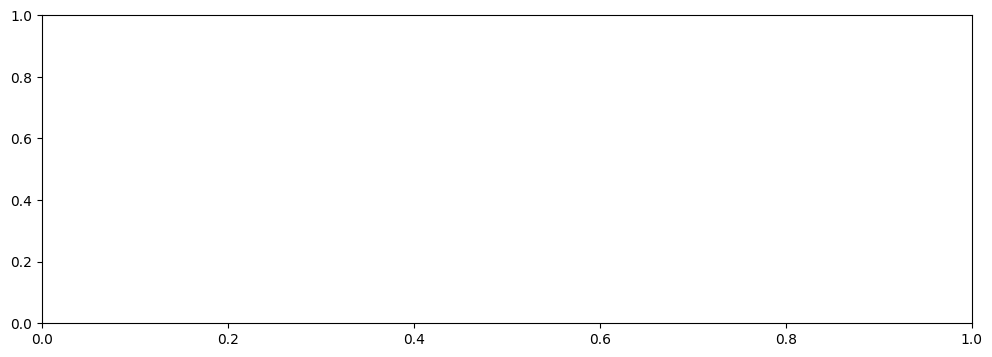

In [8]:
sfm.surface_plot(values)